# FakenewsBR v6 — Notebook de carga, execução e avaliação do modelo

Run avaliado: **`D1_dedup_s42`** — BASE treinado sem as cópias extras de duplicatas exatas
(`pipeline/prepare/processed_dedup`, 473 linhas removidas só do treino; o teste é o mesmo, n = 13.661).

Modelo: **BERTimbau base (`neuralmind/bert-base-portuguese-cased`) fine-tunado** para classificação binária
(`0 = verdadeiro`, `1 = fake`), com **calibração Platt** e treino **DFR** (anti-atalho de procedência).

Este notebook:
1. carrega o modelo salvo (`best/`) e a calibração (`calibration.json`);
2. roda inferência em exemplos (com Platt aplicado como no treino);
3. recalcula **acc, macro-F1, F1/precisão/acurácia de cada classe (fake e true), PR-AUC, ROC-AUC, Brier, ECE e pior-grupo** a partir de `predictions.csv` (13.661 linhas de teste, sem GPU);
4. compara com o baseline **TF-IDF + LR**, com o **v1 antigo** (inclusive no recorte sem contaminação) e com o
   **v6 R0 anterior** (treinado antes de remover as duplicatas exatas);
5. (opcional) confere se os pesos que você tem reproduzem as predições salvas.

> **Formato do modelo:** não há `.pkl`. O modelo é um `BertForSequenceClassification` salvo com `save_pretrained`
> (`model.safetensors` + `config.json` + tokenizer) e a calibração vai em `calibration.json`. `pickle` em modelos
> transformers é frágil entre versões e inseguro; a pasta `best/` completa é o formato apropriado.

## 0. Configuração de caminhos

In [1]:
import os, sys, json, subprocess
from pathlib import Path

# --- Se estiver no Colab: envie o .zip do repositório e descompacte aqui ---
ZIP_PATH = "FakenewsBR_model-main.zip"          # ajuste se o nome for outro
if not Path("FakenewsBR_model").exists() and not Path("organizado").exists() and Path(ZIP_PATH).exists():
    subprocess.run(["unzip", "-q", "-o", ZIP_PATH], check=True)

# Run com dedup + relatório por classe (mesmos números do D1_dedup_s42 original)
RUN_ID = "D1_dedup_s42_perclass"
RUN_REL = Path("organizado") / "train" / "experimentos" / "runs" / RUN_ID

def find_repo_root():
    for base in [Path.cwd(), *Path.cwd().parents, *Path.cwd().glob("*")]:
        if (base / RUN_REL).exists():
            return base
    raise FileNotFoundError("Não achei %s. Defina REPO_ROOT manualmente." % RUN_REL)

REPO_ROOT = find_repo_root()          # ou: REPO_ROOT = Path("/caminho/para/FakenewsBR_model")
V6 = REPO_ROOT / "models" / "v6"
RUN = REPO_ROOT / RUN_REL
BEST = RUN / "best"                   # <- coloque aqui o model.safetensors
PRED_R0   = RUN / "predictions.csv"
PRED_TFIDF = V6 / "compare" / "baseline_tfidf" / "predictions.csv"
PRED_V1    = V6 / "compare" / "old_v1_on_v6" / "predictions.csv"
PRED_OLD   = V6 / "artifacts" / "full_iid_ml192_f6_on_seed42" / "predictions.csv"   # v6 antes do dedup
POOL = REPO_ROOT / "organizado" / "prepare_data" / "processed_dedup" / "v6_pool.parquet"

print("REPO_ROOT:", REPO_ROOT)
print("RUN:", RUN)
print("best/ contém:", sorted(p.name for p in BEST.iterdir()))
print("model.safetensors presente?", (BEST / "model.safetensors").exists())


REPO_ROOT: D:\residencia\FakenewsBR_model
RUN: D:\residencia\FakenewsBR_model\organizado\train\experimentos\runs\D1_dedup_s42_perclass
best/ contém: ['calibration.json', 'config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']
model.safetensors presente? True


In [2]:
# Dependências (no Colab já vêm instaladas, exceto talvez transformers recente)
import importlib
for pkg in ["numpy", "pandas", "sklearn", "matplotlib"]:
    importlib.import_module(pkg)
try:
    import torch, transformers
    print("torch", torch.__version__, "| transformers", transformers.__version__)
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print("torch/transformers ausentes: as seções de inferência serão puladas; as métricas (seção 4+) rodam sem eles.")

C:\Users\Usuario\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.13.0+cu130 | transformers 5.16.1


## 1. Métricas (cópia fiel das funções do projeto)

Copiadas de `pipeline/train/train_bertimbau_v6.py`, para que os números daqui
sejam definidos exatamente como no treino: ECE com 15 bins sobre a confiança da classe predita; **pior-grupo =
menor macro-F1 entre grupos estatisticamente confiáveis** (`n ≥ 100` e classe minoritária `≥ 20`).

Além de F1-fake, cada classe tem **precisão, F1 e acurácia da classe** (`acc_fake`, `acc_true` = fração dos exemplos daquela classe que o modelo acertou, ou seja, o recall).


In [3]:
import numpy as np, pandas as pd
from sklearn.metrics import (accuracy_score, average_precision_score,
                             brier_score_loss, f1_score, precision_score,
                             roc_auc_score)

MIN_GROUP_N, MIN_MINORITY_N = 100, 20

def expected_calibration_error(p, y, bins=15):
    p = np.asarray(p, float); y = np.asarray(y).astype(int)
    pred = (p >= 0.5).astype(int)
    conf = np.where(pred == 1, p, 1.0 - p)
    correct = (pred == y).astype(float)
    edges = np.linspace(0, 1, bins + 1); ece = 0.0
    for i in range(bins):
        m = (conf > edges[i]) & (conf <= edges[i + 1])
        if m.sum():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return float(ece)

def core_metrics(y, p, threshold=0.5):
    y = np.asarray(y).astype(int); p = np.asarray(p, float)
    pred = (p >= threshold).astype(int); two = len(np.unique(y)) > 1
    return {
        "n": int(len(y)),
        "acc": float(accuracy_score(y, pred)),
        "macro_f1": float(f1_score(y, pred, average="macro")) if two else float("nan"),
        "f1_fake": float(f1_score(y, pred, zero_division=0)),
        "f1_true": float(f1_score(y, pred, pos_label=0, zero_division=0)),
        "prec_fake": float(precision_score(y, pred, zero_division=0)),
        "prec_true": float(precision_score(y, pred, pos_label=0, zero_division=0)),
        # acuracia da classe = recall da classe (acertos entre os exemplos dela)
        "acc_fake": float((pred[y == 1] == 1).mean()) if (y == 1).any() else float("nan"),
        "acc_true": float((pred[y == 0] == 0).mean()) if (y == 0).any() else float("nan"),
        "brier": float(brier_score_loss(y, p)) if two else float("nan"),
        "ece": expected_calibration_error(p, y),
        "roc_auc": float(roc_auc_score(y, p)) if two else float("nan"),
        "pr_auc": float(average_precision_score(y, p)) if two else float("nan"),
    }

def per_group(df, y, p, col="group", min_n=30, threshold=0.5):
    rows = []
    for name, idx in df.groupby(col).indices.items():
        if len(idx) < min_n:
            continue
        yi = y[idx]; m = core_metrics(yi, p[idx], threshold)
        m[col] = name
        m["fake_%"] = round(float(yi.mean() * 100), 1)
        m["minoria_n"] = int(min(np.bincount(yi, minlength=2)))
        m["confiavel"] = bool(len(idx) >= MIN_GROUP_N and m["minoria_n"] >= MIN_MINORITY_N)
        rows.append(m)
    cols = [col, "n", "minoria_n", "fake_%", "acc", "acc_fake", "acc_true", "macro_f1", "f1_fake", "f1_true",
            "roc_auc", "pr_auc", "ece", "confiavel"]
    return pd.DataFrame(rows)[cols].sort_values("macro_f1", na_position="last")

def worst_group_f1(df, y, p, col="group", threshold=0.5):
    tab = per_group(df.reset_index(drop=True), y, p, col=col, threshold=threshold)
    tab = tab[tab["confiavel"] & tab["macro_f1"].notna()]
    return (float(tab["macro_f1"].min()), tab.iloc[0][col]) if len(tab) else (float("nan"), None)

def platt(z, a, b):
    """p = sigmoid(a*z + b), com z = logit_fake - logit_true (idêntico ao apply_platt do treino)."""
    return 1.0 / (1.0 + np.exp(-np.clip(a * np.asarray(z, float) + b, -700, 700)))


def per_class(y, p, threshold=0.5):
    """Tabela fake x true: n, acurácia da classe (= recall), precisão e F1."""
    y = np.asarray(y).astype(int); m = core_metrics(y, p, threshold)
    return pd.DataFrame({c: {"n": int((y == k).sum()), "acuracia_classe": m[f"acc_{c}"],
                             "precisao": m[f"prec_{c}"], "recall": m[f"acc_{c}"], "f1": m[f"f1_{c}"]}
                         for c, k in [("fake", 1), ("true", 0)]}).T


## 2. Carregar calibração e modelo

`calibration.json` guarda **a, b** do Platt scaling, o `max_length` do treino (192) e dois limiares:
`threshold = 0.5` (primário) e `threshold_val_opt` (ótimo no conjunto de calibração).
**Sem esse arquivo as probabilidades saem descalibradas** — ele faz parte do modelo.

In [4]:
CAL = json.loads((BEST / "calibration.json").read_text(encoding="utf-8"))
A, B = CAL["platt_a"], CAL["platt_b"]
MAX_LEN, THR, THR_VAL = CAL["max_length"], CAL["threshold"], CAL["threshold_val_opt"]
print(json.dumps({k: CAL[k] for k in ["model","platt_a","platt_b","max_length","threshold","threshold_val_opt",
                                      "calib_on","calib_n","train_prior_fake","effective_prior_fake","freeze_layers","seed"]},
                 indent=2))
cfg = json.loads((BEST / "config.json").read_text())
print("arquitetura:", cfg["architectures"], "| camadas:", cfg["num_hidden_layers"], "| vocab:", cfg["vocab_size"])

{
  "model": "neuralmind/bert-base-portuguese-cased",
  "platt_a": 0.4861459730288282,
  "platt_b": 0.019796032718449322,
  "max_length": 192,
  "threshold": 0.5,
  "threshold_val_opt": 0.4600000000000001,
  "calib_on": "val_calib",
  "calib_n": 1844,
  "train_prior_fake": 0.7336325279309746,
  "effective_prior_fake": 0.6016699150009372,
  "freeze_layers": 6,
  "seed": 42
}
arquitetura: ['BertForSequenceClassification'] | camadas: 12 | vocab: 29794


In [5]:
MODEL_OK = HAS_TORCH and (BEST / "model.safetensors").exists()
if MODEL_OK:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    tok = AutoTokenizer.from_pretrained(BEST)
    model = AutoModelForSequenceClassification.from_pretrained(BEST).to(DEVICE).eval()
    print(f"Modelo carregado em {DEVICE} | parâmetros: {sum(p.numel() for p in model.parameters())/1e6:.1f}M | rótulos: {model.config.id2label}")
else:
    print("Modelo NÃO carregado:",
          "torch/transformers ausentes." if not HAS_TORCH else f"falta {BEST/'model.safetensors'}.",
          "\nBaixe o model.safetensors (Release 'modelo-v6-R0') e coloque dentro de best/.")


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9021.46it/s]


Modelo carregado em cuda | parâmetros: 108.9M | rótulos: {0: 'LABEL_0', 1: 'LABEL_1'}


In [6]:
@torch.no_grad() if HAS_TORCH else (lambda f: f)
def predict(texts, batch_size=32):
    """Retorna DataFrame com logits, z, p_raw, p_cal (Platt) e classe predita em 0.5 e no limiar de validação."""
    assert MODEL_OK, "Modelo não carregado (veja a célula anterior)."
    texts = [str(t) for t in texts]
    z_all, lg_all = [], []
    for i in range(0, len(texts), batch_size):
        enc = tok(texts[i:i+batch_size], truncation=True, max_length=MAX_LEN,
                  padding=True, return_tensors="pt").to(DEVICE)
        lg = model(**enc).logits.float().cpu().numpy()
        lg_all.append(lg)
    lg = np.concatenate(lg_all)
    z = lg[:, 1] - lg[:, 0]
    p_cal = platt(z, A, B)
    return pd.DataFrame({"logit0": lg[:, 0], "logit1": lg[:, 1], "z": z,
                         "p_raw": platt(z, 1.0, 0.0), "p_cal": p_cal,
                         "pred_05": (p_cal >= THR).astype(int),
                         "pred_val_thr": (p_cal >= THR_VAL).astype(int)})

## 3. Inferência em exemplos

Textos de demonstração (substitua pelos seus). `p_cal` é a probabilidade calibrada de a notícia ser **fake**.

In [7]:
exemplos = [
    "URGENTE: compartilhe antes que apaguem! Governo vai confiscar a poupança de todos os brasileiros na segunda-feira.",
    "O Banco Central manteve a taxa Selic em reunião do Copom e divulgou ata detalhando a decisão.",
    "Vídeo mostra vacina contra a covid-19 que altera o DNA das pessoas, segundo mensagem que circula no WhatsApp.",
    "A Câmara dos Deputados aprovou nesta quarta-feira o projeto que trata do marco legal do saneamento.",
]
if MODEL_OK:
    out = predict(exemplos)
    out.insert(0, "texto", [t[:90] + "…" for t in exemplos])
    out["classe"] = np.where(out["pred_05"] == 1, "FAKE", "VERDADEIRA")
    display(out[["texto", "p_raw", "p_cal", "classe"]].round(4))
else:
    print("Pulado: modelo não carregado.")

,texto,p_raw,p_cal,classe
0,URGENTE: compartilhe antes que apaguem! Govern...,0.9967,0.9427,FAKE
1,O Banco Central manteve a taxa Selic em reuniã...,0.9892,0.9017,FAKE
2,Vídeo mostra vacina contra a covid-19 que alte...,0.9992,0.9702,FAKE
3,A Câmara dos Deputados aprovou nesta quarta-fe...,0.1836,0.3306,VERDADEIRA


## 4. Avaliação no teste (`full_iid`, n = 13.661) a partir de `predictions.csv`

`predictions.csv` contém, para cada linha, `z = logit1 − logit0`, `p_cal = sigmoid(a·z + b)` e metadados (grupo, canal…).
Aqui só usamos a partição `split == "test"`. Não precisa de GPU.

In [8]:
pred = pd.read_csv(PRED_R0, low_memory=False)
test = pred[pred["split"] == "test"].reset_index(drop=True)
y = test["y_true"].to_numpy().astype(int)
print("splits no arquivo:", pred["split"].value_counts().to_dict())
print(f"teste: n={len(test)} | %fake={y.mean()*100:.2f}")

# sanidade: p_cal do arquivo == Platt(a,b) aplicado ao z do arquivo
err = np.abs(platt(test["z"], A, B) - test["p_cal"]).max()
print(f"Platt reproduzido a partir de calibration.json: erro máx = {err:.2e}")

splits no arquivo: {'test': 13661, 'val_sel': 9108, 'val_calib': 4554}
teste: n=13661 | %fake=73.31
Platt reproduzido a partir de calibration.json: erro máx = 1.11e-16


In [9]:
m05  = core_metrics(y, test["p_cal"], THR)
mval = core_metrics(y, test["p_cal"], THR_VAL)
wg05,  g05  = worst_group_f1(test, y, test["p_cal"].to_numpy(), threshold=THR)
wgval, gval = worst_group_f1(test, y, test["p_cal"].to_numpy(), threshold=THR_VAL)

res = pd.DataFrame({f"limiar {THR}": {**m05,  "pior_grupo": wg05,  "grupo_pior": g05},
                    f"limiar {THR_VAL:.2f} (val)": {**mval, "pior_grupo": wgval, "grupo_pior": gval}})
display(res)

# Métricas de cada classe (fake e true) nos dois limiares
for thr, nome in [(THR, f"limiar {THR}"), (THR_VAL, f"limiar {THR_VAL:.2f} (val)")]:
    print(f"\nPOR CLASSE — {nome}")
    display(per_class(y, test["p_cal"], thr).round(4))

# Comparação com o metrics.json salvo pelo treino
saved_all = json.loads((RUN / "metrics.json").read_text(encoding="utf-8"))
for key, m, wg in [("test", m05, wg05), ("test_at_val_threshold", mval, wgval)]:
    saved = saved_all[key]
    print(f"\nconferência com metrics.json [{key}]:")
    for k in ["acc", "macro_f1", "f1_fake", "f1_true", "prec_fake", "prec_true", "acc_fake", "acc_true",
              "pr_auc", "roc_auc", "ece"]:
        if k in saved:
            ok = "ok" if abs(m[k] - saved[k]) < 1e-6 else "DIFERENTE"
            print(f"  {k:9s} recalculado={m[k]:.4f}  metrics.json={saved[k]:.4f}  {ok}")
    if "worst_group_macro_f1" in saved:
        ok = "ok" if abs(wg - saved["worst_group_macro_f1"]) < 1e-6 else "DIFERENTE"
        print(f"  pior-grupo recalculado={wg:.4f}  metrics.json={saved['worst_group_macro_f1']:.4f}  {ok}")


,limiar 0.5,limiar 0.46 (val)
n,13661,13661
acc,0.825123,0.827685
macro_f1,0.784957,0.780249
f1_fake,0.877894,0.882347
f1_true,0.69202,0.678151
prec_fake,0.899267,0.883318
prec_true,0.652883,0.676118
acc_fake,0.857514,0.881378
acc_true,0.736149,0.680197
brier,0.115309,0.115309



POR CLASSE — limiar 0.5


,n,acuracia_classe,precisao,recall,f1
fake,10015.0,0.8575,0.8993,0.8575,0.8779
true,3646.0,0.7361,0.6529,0.7361,0.6920



POR CLASSE — limiar 0.46 (val)


,n,acuracia_classe,precisao,recall,f1
fake,10015.0,0.8814,0.8833,0.8814,0.8823
true,3646.0,0.6802,0.6761,0.6802,0.6782



conferência com metrics.json [test]:
  acc       recalculado=0.8251  metrics.json=0.8251  ok
  macro_f1  recalculado=0.7850  metrics.json=0.7850  ok
  f1_fake   recalculado=0.8779  metrics.json=0.8779  ok
  f1_true   recalculado=0.6920  metrics.json=0.6920  ok
  prec_fake recalculado=0.8993  metrics.json=0.8993  ok
  prec_true recalculado=0.6529  metrics.json=0.6529  ok
  acc_fake  recalculado=0.8575  metrics.json=0.8575  ok
  acc_true  recalculado=0.7361  metrics.json=0.7361  ok
  pr_auc    recalculado=0.9586  metrics.json=0.9586  ok
  roc_auc   recalculado=0.8956  metrics.json=0.8956  ok
  ece       recalculado=0.0236  metrics.json=0.0236  ok
  pior-grupo recalculado=0.6173  metrics.json=0.6173  ok

conferência com metrics.json [test_at_val_threshold]:
  acc       recalculado=0.8277  metrics.json=0.8277  ok
  macro_f1  recalculado=0.7802  metrics.json=0.7802  ok
  f1_fake   recalculado=0.8823  metrics.json=0.8823  ok
  f1_true   recalculado=0.6782  metrics.json=0.6782  ok
  prec_fak

### Métricas por grupo (pior → melhor; só `confiavel=True` entra no pior-grupo)

In [10]:
tab = per_group(test, y, test["p_cal"].to_numpy(), threshold=THR)
display(tab.round(4))
print(f"... {len(tab)} grupos no total; {int(tab['confiavel'].sum())} confiáveis.")

,group,n,minoria_n,fake_%,acc,acc_fake,acc_true,macro_f1,f1_fake,f1_true,roc_auc,pr_auc,ece,confiavel
5,FC_AOSFATOS,122,1,99.2,0.9426,0.9504,0.0000,0.4852,0.9705,0.0000,0.8099,0.9983,0.0466,False
9,FC_COMPROVA,143,3,97.9,0.9441,0.9643,0.0000,0.4856,0.9712,0.0000,0.5500,0.9862,0.0576,False
15,FC_OBSERVADOR,124,2,98.4,0.9516,0.9672,0.0000,0.4876,0.9752,0.0000,0.7869,0.9959,0.0976,False
12,FC_FOLHA,32,1,96.9,0.9688,1.0000,0.0000,0.4921,0.9841,0.0000,0.6613,0.9867,0.0108,False
14,FC_LUPA,215,4,98.1,0.9535,0.9668,0.2500,0.5714,0.9761,0.1667,0.8128,0.9957,0.1093,False
3,EXT_LIARBR,1049,423,40.3,0.6215,0.6407,0.6086,0.6173,0.5772,0.6575,0.6552,0.5542,0.0360,True
16,FC_POLIGRAFO,1625,622,61.7,0.6338,0.5055,0.8408,0.6338,0.6302,0.6374,0.7274,0.8242,0.0422,True
10,FC_EFARSAS,481,62,87.1,0.8524,0.9189,0.4032,0.6644,0.9156,0.4132,0.7405,0.9440,0.0483,True
2,EXT_AVERITECBR,439,119,72.9,0.7175,0.7469,0.6387,0.6724,0.7940,0.5507,0.7555,0.8761,0.0543,True
22,MuMiN-PT,33,4,87.9,0.8485,0.8966,0.5000,0.6784,0.9123,0.4444,0.6983,0.9336,0.1662,False


... 29 grupos no total; 7 confiáveis.


### Por canal

In [11]:
rows = []
for ch, g in test.groupby("channel"):
    yy = g["y_true"].to_numpy().astype(int)
    if len(g) >= 30 and len(np.unique(yy)) > 1:
        m = core_metrics(yy, g["p_cal"], THR); rows.append({"canal": ch, "n": m["n"], "acc": m["acc"], "acc_fake": m["acc_fake"], "acc_true": m["acc_true"],
                     "macro_f1": m["macro_f1"], "f1_fake": m["f1_fake"], "f1_true": m["f1_true"], "ece": m["ece"]})
display(pd.DataFrame(rows).sort_values("macro_f1").round(4))

,canal,n,acc,acc_fake,acc_true,macro_f1,f1_fake,f1_true,ece
5,social,387,0.9380,0.9426,0.5000,0.5553,0.9678,0.1429,0.0521
2,external_claim,1488,0.6499,0.6864,0.6134,0.6494,0.6619,0.6369,0.0273
0,agency_claim,8477,0.8530,0.8594,0.7847,0.6951,0.9145,0.4756,0.0433
6,whatsapp,957,0.7116,0.8431,0.6333,0.7096,0.6856,0.7336,0.0623
1,covid,346,0.8121,0.8741,0.7725,0.8089,0.7841,0.8338,0.0398
4,portal,1081,0.9732,0.9885,0.9532,0.9726,0.9766,0.9686,0.0314
3,llm,45,0.9778,0.9655,1.0000,0.9761,0.9825,0.9697,0.0100


### Calibração: antes × depois do Platt

ECE antes do Platt (p_raw): 0.0678  |  depois (p_cal): 0.0236


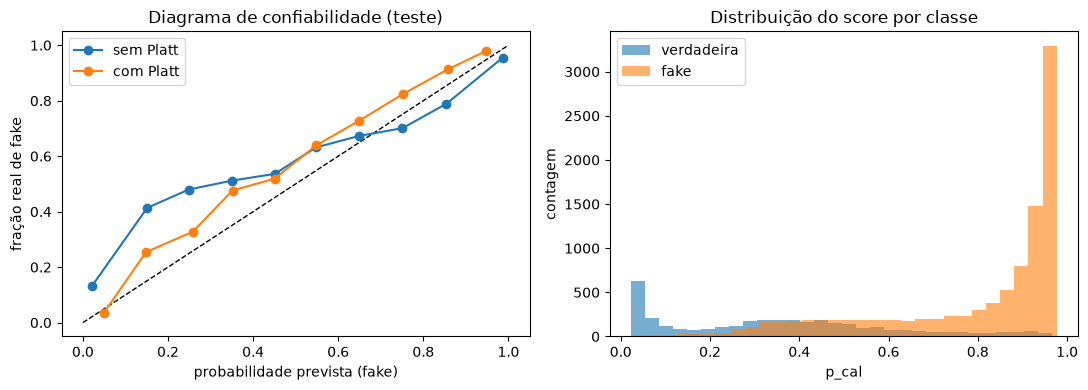

In [12]:
import matplotlib.pyplot as plt

def reliability(p, y, bins=10):
    edges = np.linspace(0, 1, bins + 1); xs, ys = [], []
    for i in range(bins):
        m = (p > edges[i]) & (p <= edges[i+1]) if i else (p >= edges[i]) & (p <= edges[i+1])
        if m.sum() >= 20: xs.append(p[m].mean()); ys.append(y[m].mean())
    return xs, ys

p_raw, p_cal = test["p_raw"].to_numpy(), test["p_cal"].to_numpy()
print(f"ECE antes do Platt (p_raw): {expected_calibration_error(p_raw, y):.4f}  |  depois (p_cal): {expected_calibration_error(p_cal, y):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot([0,1],[0,1],"k--",lw=1)
for p_, lbl in [(p_raw,"sem Platt"),(p_cal,"com Platt")]:
    xs, ys = reliability(p_, y); ax[0].plot(xs, ys, "o-", label=lbl)
ax[0].set(xlabel="probabilidade prevista (fake)", ylabel="fração real de fake", title="Diagrama de confiabilidade (teste)"); ax[0].legend()
ax[1].hist(p_cal[y==0], bins=30, alpha=.6, label="verdadeira"); ax[1].hist(p_cal[y==1], bins=30, alpha=.6, label="fake")
ax[1].set(xlabel="p_cal", ylabel="contagem", title="Distribuição do score por classe"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Comparação com baselines (mesmo teste, n = 13.661)

* **Maioria:** sempre prevê *fake* (piso trivial).
* **TF-IDF + LR + Platt:** baseline linear forte.
* **v1 antigo:** 30,36 % do teste v6 estava no treino dele (`contam_v1_train`), então reportamos também o **recorte limpo**.
* **v6 R0 anterior:** mesmo BERTimbau v6, treinado antes do dedup (`legacy/models/v6/artifacts/full_iid_ml192_f6_on_seed42`).


In [13]:
def summarize(name, df, p_col="p_cal", thr=0.5):
    yy = df["y_true"].to_numpy().astype(int); pp = df[p_col].to_numpy()
    m = core_metrics(yy, pp, thr); wg, g = worst_group_f1(df, yy, pp, threshold=thr)
    return {"modelo": name, "n": m["n"], "acc": m["acc"], "macro_f1": m["macro_f1"], "f1_fake": m["f1_fake"], "f1_true": m["f1_true"],
            "acc_fake": m["acc_fake"], "acc_true": m["acc_true"],
            "pr_auc": m["pr_auc"], "roc_auc": m["roc_auc"], "brier": m["brier"], "ece": m["ece"], "pior_grupo": wg, "grupo_pior": g}

tfidf = pd.read_csv(PRED_TFIDF, low_memory=False)
v1    = pd.read_csv(PRED_V1, low_memory=False)
old   = pd.read_csv(PRED_OLD, low_memory=False); old = old[old["split"] == "test"]

maj = test.assign(p_cal=1.0)       # prevê tudo como fake
rows = [summarize("Maioria (tudo fake)", maj),
        summarize("TF-IDF + LR + Platt", tfidf),
        summarize(f"v1 antigo (contaminado {v1['contam_v1_train'].mean()*100:.1f}%)", v1),
        summarize("v1 antigo — recorte limpo", v1[~v1["contam_v1_train"].astype(bool)]),
        summarize("BERTimbau v6 R0 (antes do dedup)", old),
        summarize("BERTimbau v6 D1_dedup (este modelo)", test)]
comp = pd.DataFrame(rows).set_index("modelo")
display(comp.round(4))

,n,acc,macro_f1,f1_fake,f1_true,acc_fake,acc_true,pr_auc,roc_auc,brier,ece,pior_grupo,grupo_pior
modelo,,,,,,,,,,,,,
Maioria (tudo fake),13661,0.7331,0.4230,0.8460,0.0000,1.0000,0.0000,0.7331,0.5000,0.2669,0.2669,0.2717,FakeWhatsApp.BR_2018
TF-IDF + LR + Platt,13661,0.8032,0.7404,0.8681,0.6126,0.8835,0.5828,0.9357,0.8489,0.1380,0.0468,0.5070,FC_EFARSAS
v1 antigo (contaminado 30.4%),13661,0.8051,0.6943,0.8784,0.5103,0.9598,0.3804,0.9353,0.8453,0.1385,0.0625,0.3008,EXT_LIARBR
v1 antigo — recorte limpo,9514,0.7650,0.5974,0.8571,0.3377,0.9505,0.2320,0.9144,0.7838,0.1679,0.0959,0.3008,EXT_LIARBR
BERTimbau v6 R0 (antes do dedup),13661,0.8061,0.7675,0.8622,0.6728,0.8277,0.7468,0.9512,0.8800,0.1252,0.0315,0.5410,EXT_LIARBR
BERTimbau v6 D1_dedup (este modelo),13661,0.8251,0.7850,0.8779,0.6920,0.8575,0.7361,0.9586,0.8956,0.1153,0.0236,0.6173,EXT_LIARBR


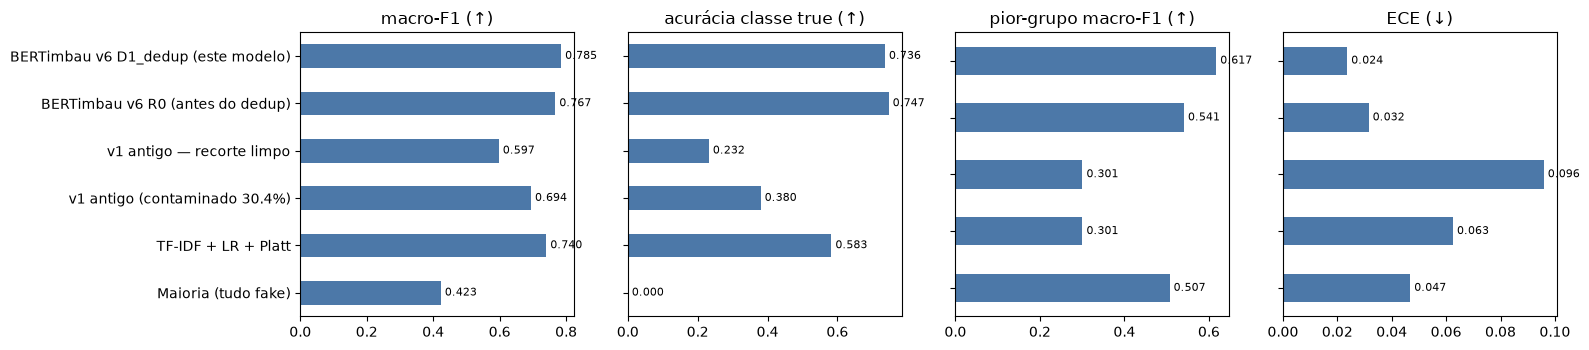

In [14]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3.6))
for a_, col, ttl in zip(ax, ["macro_f1", "acc_true", "pior_grupo", "ece"],
                         ["macro-F1 (↑)", "acurácia classe true (↑)", "pior-grupo macro-F1 (↑)", "ECE (↓)"]):
    s = comp[col].drop("Maioria (tudo fake)", errors="ignore") if col not in ("macro_f1", "acc_true") else comp[col]
    s.plot.barh(ax=a_, color="#4c78a8"); a_.set_title(ttl); a_.set_ylabel("")
    for i, v in enumerate(s.values): a_.text(v, i, f" {v:.3f}", va="center", fontsize=8)
    if a_ is not ax[0]: a_.set_yticklabels([])
plt.tight_layout(); plt.show()

## 6. (Opcional) Os pesos que você baixou reproduzem estas predições?

O `predictions.csv` guarda `p_cal` por `rid`. Se você tiver o pool de dados deduplicado (`organizado/prepare_data/processed_dedup/v6_pool.parquet`), esta célula reinfera ~300 linhas de teste com os **seus** pesos e compara com o arquivo.
Diferença ≈ 0 ⇒ pesos e `predictions.csv` são do mesmo treino.

In [15]:
def is_real_parquet(p):
    return p.exists() and p.read_bytes()[:4] == b"PAR1"

if MODEL_OK and is_real_parquet(POOL):
    pool = pd.read_parquet(POOL)
    samp = test.sample(300, random_state=0).merge(pool[["rid", "text_no_url"]], on="rid", how="inner")
    new = predict(samp["text_no_url"].tolist())
    d = np.abs(new["p_cal"].to_numpy() - samp["p_cal"].to_numpy())
    print(f"n={len(samp)} | |Δp_cal| médio={d.mean():.4f} | máx={d.max():.4f} | concordância de classe={((new['pred_05'].values)==(samp['pred_05'].values)).mean():.3f}")
    print("OK: pesos consistentes com predictions.csv" if d.mean() < 0.01 else
          "ATENÇÃO: pesos diferem do run que gerou predictions.csv/calibration.json (veja seção 7).")
else:
    print(f"Pulado: precisa do model.safetensors + de {POOL}. Não afeta as demais seções.")

n=300 | |Δp_cal| médio=0.0007 | máx=0.0151 | concordância de classe=1.000
OK: pesos consistentes com predictions.csv


## 7. Procedência deste run

`D1_dedup_s42_perclass` é um retreino do `D1_dedup_s42` (mesmos argumentos, seed 42, `cudnn.deterministic=True`)
com o relatório por classe ligado. Os dois runs deram as **mesmas métricas** no teste (acc 0,8251, macro-F1 0,7850,
pior-grupo 0,6173, melhor época 3), então os pesos em `best/`, o `calibration.json` e o `predictions.csv` deste diretório
são de uma única execução.

O run antigo `legacy/models/v6/artifacts/full_iid_ml192_f6_on_seed42` (antes do dedup) aparece só como linha de comparação na seção 5.
